In [1]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr, kendalltau

PROCESSED_DIR = Path("data/processed")
TABLES_DIR = Path("outputs/tables")
FIGURES_DIR = Path("outputs/figures")
MODELS_DIR = Path("outputs/models")

for folder in [TABLES_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

cards = pd.read_csv(PROCESSED_DIR / "pokemon_priced_features.csv", low_memory=False)
features = pd.read_csv(TABLES_DIR / "final_model_features.csv")["feature"].tolist()
model = joblib.load(MODELS_DIR / "final_lightgbm_holdout_model.joblib")

X = cards[features]
y = cards["Log_Value"]

indices = np.arange(len(cards))
train_idx, test_idx = train_test_split(indices, test_size=.2, random_state=42)
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['card_number_printed_total' 'card_position_ratio_intrinsic']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['card_number_printed_total' 'card_p

In [2]:
actual_price = np.expm1(y_test)
predicted_price = np.maximum(np.expm1(test_pred), 0)

metrics = pd.DataFrame([{
    "train_log_MAE": mean_absolute_error(y_train, train_pred),
    "test_log_MAE": mean_absolute_error(y_test, test_pred),
    "train_log_RMSE": mean_squared_error(y_train, train_pred) ** .5,
    "test_log_RMSE": mean_squared_error(y_test, test_pred) ** .5,
    "train_log_R2": r2_score(y_train, train_pred),
    "test_log_R2": r2_score(y_test, test_pred),
    "test_price_MAE": mean_absolute_error(actual_price, predicted_price),
    "test_price_RMSE": mean_squared_error(actual_price, predicted_price) ** .5,
    "spearman_rank": spearmanr(y_test, test_pred).correlation,
    "kendall_rank": kendalltau(y_test, test_pred).correlation
}])

display(metrics.T)

holdout = cards.loc[test_idx].reset_index(drop=True)
holdout["actual_log_value"] = np.asarray(y_test)
holdout["predicted_log_value"] = test_pred
holdout["residual_log"] = holdout["actual_log_value"] - holdout["predicted_log_value"]
holdout["absolute_log_error"] = holdout["residual_log"].abs()
holdout["actual_value"] = np.expm1(holdout["actual_log_value"])
holdout["predicted_value"] = np.maximum(np.expm1(holdout["predicted_log_value"]), 0)
holdout["residual_value"] = holdout["actual_value"] - holdout["predicted_value"]
holdout["absolute_value_error"] = holdout["residual_value"].abs()

metrics.to_csv(TABLES_DIR / "interpretation_metrics.csv", index=False, encoding="utf-8-sig")
holdout.to_csv(TABLES_DIR / "lightgbm_holdout_predictions.csv", index=False, encoding="utf-8-sig")

,0
train_log_MAE,0.221738
test_log_MAE,0.246741
train_log_RMSE,0.365954
test_log_RMSE,0.412865
train_log_R2,0.895452
test_log_R2,0.867634
test_price_MAE,4.821715
test_price_RMSE,38.608408
spearman_rank,0.898872
kendall_rank,0.747713


,feature,split_importance,gain_importance,gain_importance_pct
47,rarity_rank_x_set_age,996,109264.722394,19.720641
49,set_age_filled,2421,64580.786248,11.655862
5,Rarity,2377,55222.892539,9.966902
15,card_position_ratio_api_printed,2090,47928.619619,8.650396
19,holo_x_set_age,617,32620.118037,5.887441
33,is_popular_pokemon,257,26355.745962,4.756816
45,rarity_group,161,24389.283795,4.401899
44,popular_pokemon_x_set_age,692,23673.574801,4.272725
40,is_stamp_card,208,18267.490039,3.297007
6,api_printed_total_filled,1285,15165.014884,2.737057


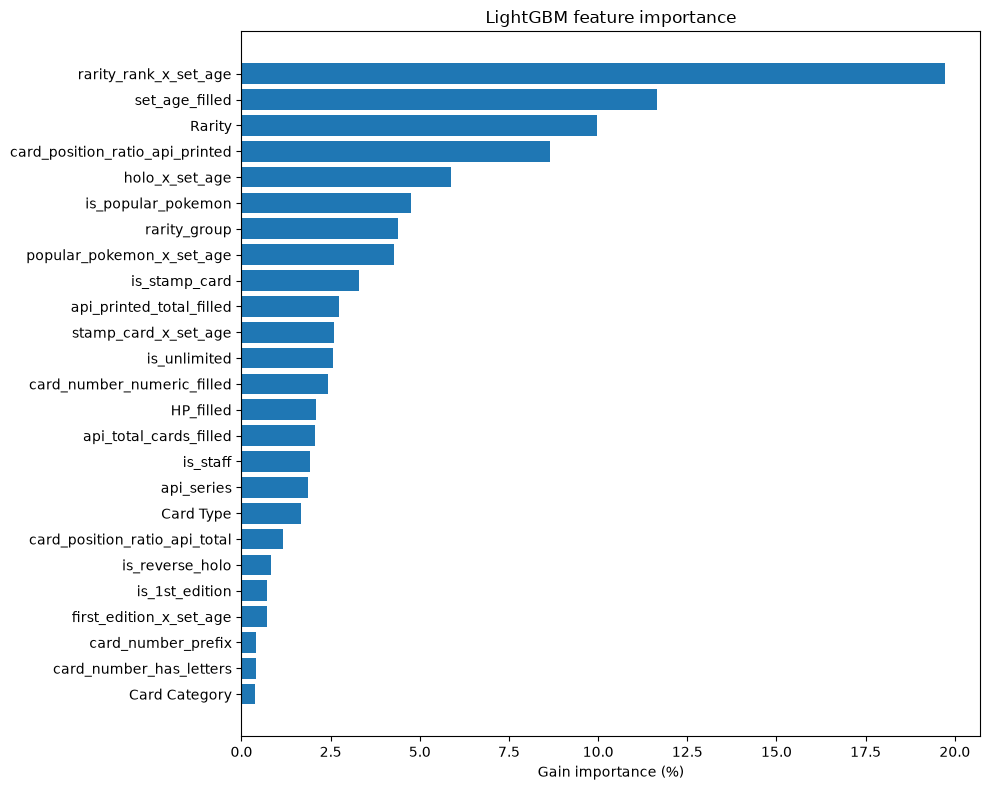

In [3]:
preprocessor = model.named_steps["preprocessor"]
estimator = model.named_steps["model"]
encoded_names = preprocessor.get_feature_names_out()

def original_feature(encoded):
    name = encoded.split("__", 1)[-1]
    for feature in sorted(features, key=len, reverse=True):
        if name == feature or name.startswith(feature + "_"):
            return feature
    return name

importance = pd.DataFrame({
    "encoded_feature": encoded_names,
    "split_importance": estimator.booster_.feature_importance("split"),
    "gain_importance": estimator.booster_.feature_importance("gain")
})

importance["feature"] = importance["encoded_feature"].map(original_feature)

gain = importance.groupby("feature", as_index=False).agg(
    split_importance=("split_importance", "sum"),
    gain_importance=("gain_importance", "sum")
).sort_values("gain_importance", ascending=False)

gain["gain_importance_pct"] = gain["gain_importance"] / gain["gain_importance"].sum() * 100

display(gain.head(30))
gain.to_csv(TABLES_DIR / "lightgbm_gain_importance.csv", index=False, encoding="utf-8-sig")

plot_data = gain.head(25).sort_values("gain_importance_pct")
plt.figure(figsize=(10, 8))
plt.barh(plot_data["feature"], plot_data["gain_importance_pct"])
plt.xlabel("Gain importance (%)")
plt.title("LightGBM feature importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lightgbm_gain_importance.png", dpi=250)
plt.show()

In [4]:
X_perm = X_test.sample(min(2500, len(X_test)), random_state=42)
y_perm = y_test.loc[X_perm.index]

permutation = permutation_importance(
    model,
    X_perm,
    y_perm,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

permutation_table = pd.DataFrame({
    "feature": X_perm.columns,
    "importance_mean": permutation.importances_mean,
    "importance_std": permutation.importances_std
}).sort_values("importance_mean", ascending=False)

display(permutation_table.head(30))
permutation_table.to_csv(TABLES_DIR / "lightgbm_permutation_importance.csv", index=False, encoding="utf-8-sig")

C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['card_number_printed_total' 'card_position_ratio_intrinsic']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['card_number_printed_total' 'card_position_ratio_intrinsic']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature name

,feature,importance_mean,importance_std
39,set_age_filled,0.335995,0.009003
49,rarity_rank_x_set_age,0.218297,0.006755
5,Rarity,0.181415,0.006659
45,card_position_ratio_api_printed,0.145476,0.005643
41,api_printed_total_filled,0.103986,0.004851
50,holo_x_set_age,0.063265,0.002363
9,card_number_numeric_filled,0.062668,0.005580
23,is_stamp_card,0.059789,0.006545
43,api_total_cards_filled,0.045191,0.001524
32,is_popular_pokemon,0.042809,0.002773


C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['card_number_printed_total' 'card_position_ratio_intrinsic']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,feature,mean_abs_shap
49,set_age_filled,0.265133
5,Rarity,0.230617
47,rarity_rank_x_set_age,0.167607
15,card_position_ratio_api_printed,0.114876
45,rarity_group,0.084142
6,api_printed_total_filled,0.083055
19,holo_x_set_age,0.070058
33,is_popular_pokemon,0.065739
2,Card Type,0.054323
8,api_series,0.047548


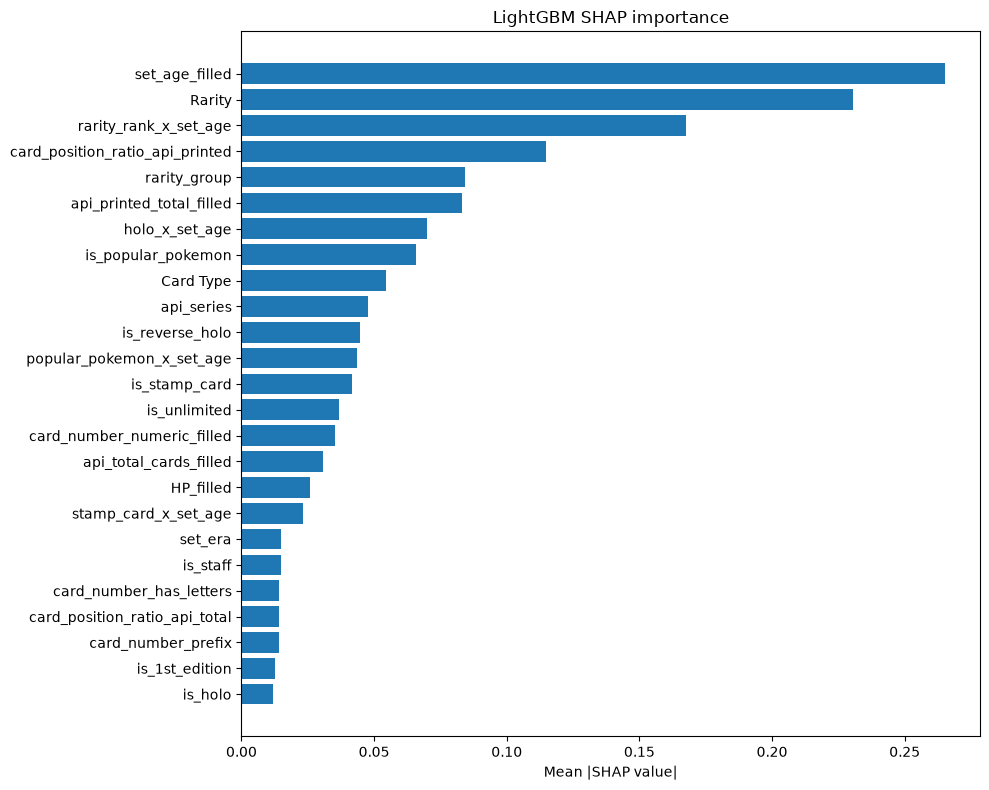

In [5]:
X_shap = X_test.sample(min(1000, len(X_test)), random_state=42)
X_shap_encoded = preprocessor.transform(X_shap)

explainer = shap.TreeExplainer(estimator)
shap_values = explainer.shap_values(X_shap_encoded)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_table = pd.DataFrame({
    "encoded_feature": np.ravel(encoded_names),
    "mean_abs_shap": np.ravel(np.abs(shap_values).mean(axis=0))
})
shap_table["feature"] = shap_table["encoded_feature"].map(original_feature)

shap_summary = shap_table.groupby("feature", as_index=False)["mean_abs_shap"].sum()
shap_summary = shap_summary.sort_values("mean_abs_shap", ascending=False)

display(shap_summary.head(30))
shap_table.to_csv(TABLES_DIR / "lightgbm_shap_encoded.csv", index=False, encoding="utf-8-sig")
shap_summary.to_csv(TABLES_DIR / "lightgbm_shap_summary.csv", index=False, encoding="utf-8-sig")

plot_data = shap_summary.head(25).sort_values("mean_abs_shap")
plt.figure(figsize=(10, 8))
plt.barh(plot_data["feature"], plot_data["mean_abs_shap"])
plt.xlabel("Mean |SHAP value|")
plt.title("LightGBM SHAP importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lightgbm_shap_importance.png", dpi=250)
plt.show()

In [6]:
feature_groups = {
    "Rarity": ["Rarity", "rarity_group", "rarity_rank"],
    "Card type and HP": ["Card Type", "Card Category", "Card Category V2", "HP_filled", "HP_missing"],
    "Intrinsic card number": [
        "card_number_missing", "card_number_numeric_filled", "card_number_printed_total",
        "card_number_has_letters", "card_number_prefix",
        "card_position_ratio_intrinsic", "card_position_ratio_intrinsic_missing",
        "is_secret_rare_intrinsic"
    ],
    "Special-card flags": [
        "is_holo", "is_reverse_holo", "is_non_holo", "is_alternate_art",
        "is_1st_edition", "is_unlimited", "is_error_card", "is_stamp_card",
        "is_prerelease", "is_staff", "is_champion", "is_trainer_deck",
        "is_world_championship", "is_oversize", "is_prototype", "is_promo_set"
    ],
    "Pokemon popularity": [
        "is_popular_pokemon", "is_charizard", "is_pikachu",
        "is_eeveelution", "is_legendary_or_mythical"
    ],
    "External set metadata": [
        "api_series", "set_era", "set_age_filled", "set_age_missing",
        "api_printed_total_filled", "api_printed_total_missing",
        "api_total_cards_filled", "api_total_cards_missing",
        "card_position_ratio_api_printed", "card_position_ratio_api_total",
        "is_above_api_printed_total", "is_above_api_total_cards"
    ],
    "Extrinsic interactions": [
        "rarity_rank_x_set_age", "holo_x_set_age", "secret_rare_x_set_age",
        "popular_pokemon_x_set_age", "stamp_card_x_set_age", "first_edition_x_set_age"
    ]
}

baseline_rmse = mean_squared_error(y_perm, model.predict(X_perm)) ** .5
rng = np.random.default_rng(42)
group_rows = []

for name, columns in feature_groups.items():
    columns = [col for col in columns if col in X_perm.columns]
    shuffled = X_perm.copy()

    for col in columns:
        shuffled[col] = rng.permutation(shuffled[col].to_numpy())

    shuffled_rmse = mean_squared_error(y_perm, model.predict(shuffled)) ** .5

    group_rows.append({
        "feature_group": name,
        "feature_count": len(columns),
        "RMSE_increase": shuffled_rmse - baseline_rmse
    })

group_importance = pd.DataFrame(group_rows).sort_values("RMSE_increase", ascending=False)
display(group_importance)
group_importance.to_csv(TABLES_DIR / "lightgbm_group_importance.csv", index=False, encoding="utf-8-sig")

C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['card_number_printed_total' 'card_position_ratio_intrinsic']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['card_number_printed_total' 'card_position_ratio_intrinsic']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature name

,feature_group,feature_count,RMSE_increase
5,External set metadata,12,0.480502
6,Extrinsic interactions,6,0.310336
0,Rarity,3,0.201716
3,Special-card flags,16,0.191417
2,Intrinsic card number,8,0.084346
1,Card type and HP,5,0.078158
4,Pokemon popularity,5,0.059961


,price_band,card_count,mean_actual_value,mean_abs_log_error,mean_abs_value_error
0,Under £1,4286,0.406759,0.121985,0.221105
1,£1-£5,1515,2.403868,0.342123,1.336712
2,£5-£20,842,9.961532,0.471937,4.870326
3,£20-£100,383,44.745300,0.590979,20.473007
4,£100+,121,329.732479,0.814818,161.537538


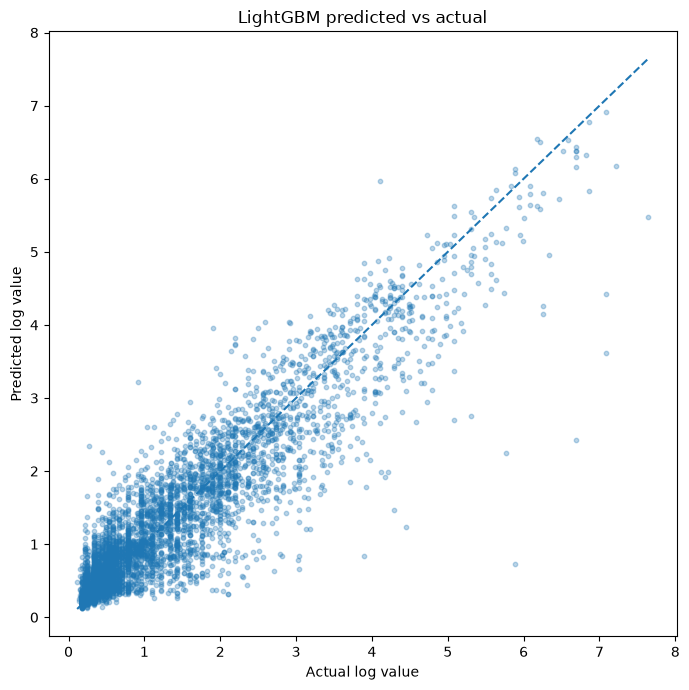

In [7]:
price_bins = [0, 1, 5, 20, 100, np.inf]
price_labels = ["Under £1", "£1-£5", "£5-£20", "£20-£100", "£100+"]

holdout["price_band"] = pd.cut(
    holdout["actual_value"],
    price_bins,
    labels=price_labels,
    include_lowest=True
)

error_by_band = holdout.groupby("price_band", observed=False).agg(
    card_count=("actual_value", "size"),
    mean_actual_value=("actual_value", "mean"),
    mean_abs_log_error=("absolute_log_error", "mean"),
    mean_abs_value_error=("absolute_value_error", "mean")
).reset_index()

display(error_by_band)
error_by_band.to_csv(TABLES_DIR / "lightgbm_error_by_price_band.csv", index=False, encoding="utf-8-sig")

holdout.nlargest(30, "residual_value").to_csv(TABLES_DIR / "lightgbm_largest_underpredictions.csv", index=False, encoding="utf-8-sig")
holdout.nsmallest(30, "residual_value").to_csv(TABLES_DIR / "lightgbm_largest_overpredictions.csv", index=False, encoding="utf-8-sig")
holdout.nlargest(30, "absolute_value_error").to_csv(TABLES_DIR / "lightgbm_largest_absolute_errors.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(7, 7))
plt.scatter(holdout["actual_log_value"], holdout["predicted_log_value"], alpha=.3, s=10)
limits = [
    holdout[["actual_log_value", "predicted_log_value"]].min().min(),
    holdout[["actual_log_value", "predicted_log_value"]].max().max()
]
plt.plot(limits, limits, "--")
plt.xlabel("Actual log value")
plt.ylabel("Predicted log value")
plt.title("LightGBM predicted vs actual")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lightgbm_predicted_vs_actual.png", dpi=250)
plt.show()